In [1]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import regex as reg
from sklearn.pipeline import Pipeline
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import warnings

mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings

In [3]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']

channel_tuple = (latest_channel_list, bad_channels)

label_dict = {'OSBA': 0, 'OSBY': 1, 'OSDO': 2, 'OSMO': 3, 'OSSI':4}

directions = ['OSBA', 'OSBY', 'OSDO', 'OSDO','OSSI']  # Left, Right, Up, Down

In [ ]:
import mne
import numpy as np

class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=8.0, h_freq=30.0, notch_freq=50.0, fs=500.0, time_window=0.2,
                 apply_ica=True, remove_muscle=True,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])

        raw.pick('eeg')

        if self.bad_channels:
            raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=1.0, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

       # print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=500
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=1.5)
          #  print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=1.5)
          #  print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
      #  print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

       # print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    # --- extracting_data and extract_for_topomap unchanged ---
    def extracting_data(self):
        classes = ['BA', 'BY', 'DO', 'MO', 'SI']
        X_all, y_all = [], []

        for cls in classes:
            starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'OS{cls}']
            ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'OE{cls}']

            for start, end in zip(starts, ends):
                segment = self.raw.copy().crop(tmin=start, tmax=end)
                data = segment.get_data(picks='eeg').astype(np.float32)  # explicit dtype

                window_samples = int(self.time_window * self.fs)
                num_windows = data.shape[1] // window_samples

                if num_windows == 0:
                    continue

                trials_split = [
                    data[:, w * window_samples:(w + 1) * window_samples]
                    for w in range(num_windows)
                ]

                X_windows = np.stack(trials_split, axis=0)
                X_all.append(X_windows)
                y_windows = np.full(X_windows.shape[0], label_dict[f'OS{cls}'])
                y_all.append(y_windows)

        if not X_all:
            raise ValueError("No matching Start/End pairs found.")

        return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)
    

    def extract_for_topomap(self):
        """
        Returns a dictionary of averaged power arrays per class for both
        Observation and Imagination states.
        """
        classes = ['BA', 'BY', 'DO', 'MO', 'SI']
        results = {}

        for cls in classes:
            # Extract Observation (O) and Imagination (I) segments
            for state_prefix in ['O', 'I']:
                starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'{state_prefix}S{cls}']
                ends = [ann['onset'] for ann in self.annotations if ann['description'] == f'{state_prefix}E{cls}']
                
                segments = []
                for start, end in zip(starts, ends):
                    # Crop the full 4-second block
                    seg = self.raw.copy().crop(tmin=start, tmax=end)
                    # Compute PSD for this specific 4s block (Alpha band)
                    psd = seg.compute_psd(fmin=8, fmax=13, method='multitaper', verbose=False)
                    # Mean power across frequencies and time for this block
                    segments.append(psd.get_data().mean(axis=-1)) 
                
                # Average across the 3 images/trials for this class
                if segments:
                    results[f"{state_prefix}_{cls}"] = np.mean(segments, axis=0)

        return results, self.raw.info

In [5]:

def plot_topo_comparison(class_results, info, class_code):
    """
    class_results: dict from extract_for_topomap
    info: mne.Info object from the processor
    class_code: one of ['BA', 'BY', 'DO', 'MO', 'SI']
    """
    obs_data = class_results.get(f"O_{class_code}")
    imag_data = class_results.get(f"I_{class_code}")

    if obs_data is None or imag_data is None:
        print(f"Missing data for {class_code}")
        return

    # Calculate Difference (Observation - Imagination)
    # If Observation power is higher (less Alpha suppression), diff is positive (Red)
    # If Imagination power is higher, diff is negative (Blue)
    diff = obs_data - imag_data

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    
    # Plot Observation
    mne.viz.plot_topomap(obs_data.flatten(), info, axes=axes[0], show=False)
    axes[0].set_title(f"Observation: {class_code}")

    # Plot Imagination
    mne.viz.plot_topomap(imag_data.flatten(), info, axes=axes[1], show=False)
    axes[1].set_title(f"Imagination: {class_code}")

    # Plot Difference
    im, _ = mne.viz.plot_topomap(diff.flatten(), info, axes=axes[2], show=False, cmap='RdBu_r')
    axes[2].set_title("Difference (Obs - Imag)")
    
    plt.colorbar(im, ax=axes[2])
    plt.show()

In [6]:
# let's plot baby class across blocks for each patient

In [7]:
import os

# Point this to the parent "Data" directory
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data"

subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 13 subjects.
Subjects identified: ['S116', 'S118', 'S5', 'S2', 'S119', 'S117', 'S3', 'S4', 'S1', 'S6', 'S115', 'S113', 'S114']


In [9]:
subject_dirs

{'S116': ['VI_S6_S1_B3__20251116_110436.mff',
  'VI_S6_S1_B1__20251116_104819.mff',
  'VI_S6_S1_B2__20251116_105637.mff'],
 'S118': ['VI_S8_S1_B1__20251119_052228.mff',
  'VI_S8_S1_B2__20251119_053014.mff',
  'VI_S8_S1_B3__20251119_053757.mff'],
 'S5': ['S5_S1_B3_1654_161025_20251016_045503.mff',
  'S5_S1_B1_1640_161025_20251016_044052.mff',
  'S5_S1_B2_1646_161025_20251016_044828.mff'],
 'S2': ['VI_S2_S1_B1_1800_08102025_20251008_060230.mff',
  'VI_S2_S1_B3_1825_08102025_20251008_062216.mff',
  'VI_S2_S1_B2_1810_08102025_20251008_061321.mff'],
 'S119': ['VI_S9_S1_B2__20251119_062424.mff',
  'VI_S9_S1_B1_A_20251119_061551.mff',
  'VI_S8_S1_B3__20251119_053757.mff'],
 'S117': ['VI_S7_S1_B3__20251118_120214.mff',
  'VI_S7_S1_B2__20251118_115409.mff',
  'VI_S7_S1_B1__20251118_114517.mff'],
 'S3': ['S3_S1_B2_1445_131025_20251013_025010.mff',
  'S3_S1_B3_1459_131025_20251013_030119.mff',
  'dummy_20251013_023702.mff'],
 'S4': ['S4_S1_B2_1550_161025_20251016_035813.mff',
  'S4_S1_B1_1540_161

S116
  Muscle artifacts: []


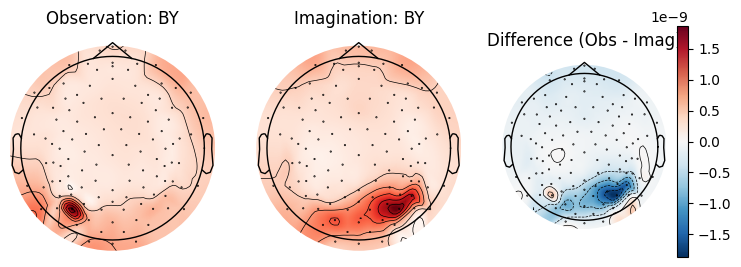

  Muscle artifacts: []


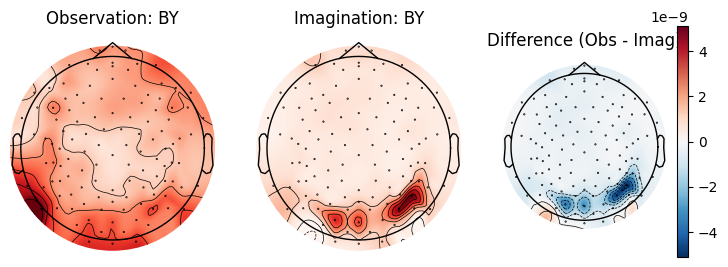

  Muscle artifacts: []


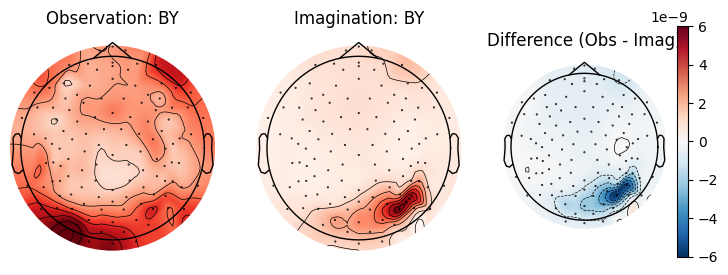

S118
  Muscle artifacts: []


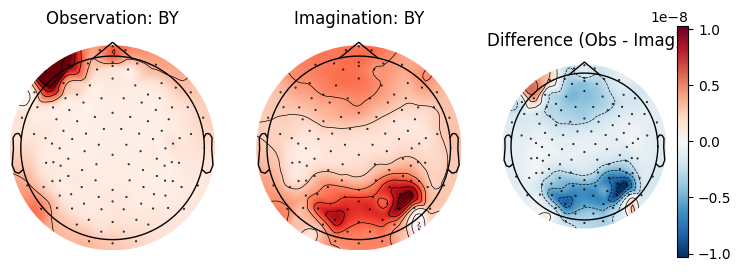

  Muscle artifacts: []


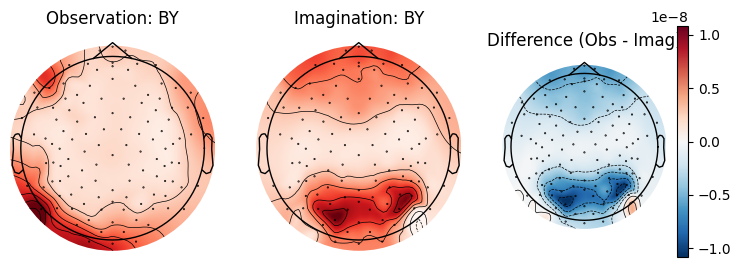

  Muscle artifacts: []


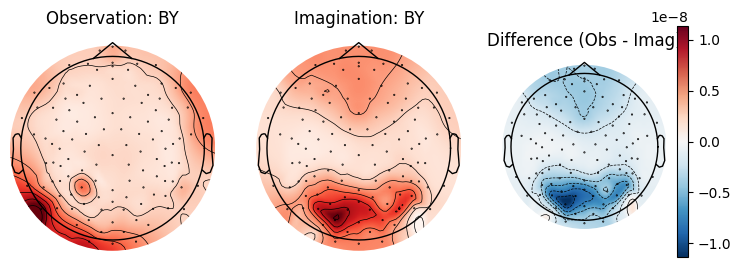

S5
  Muscle artifacts: []


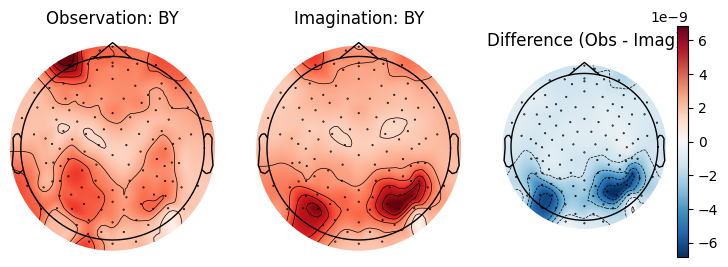

  Muscle artifacts: []


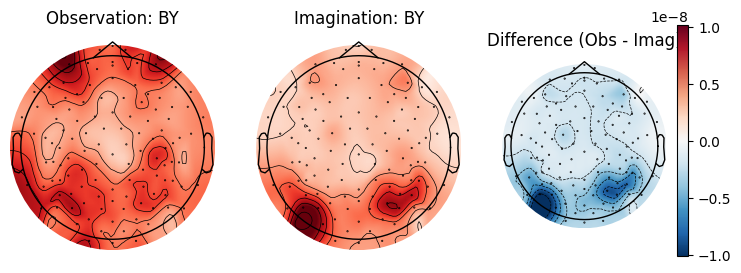

  Muscle artifacts: []


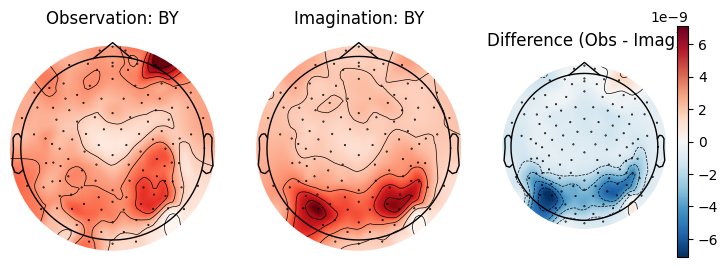

S2
  Muscle artifacts: []


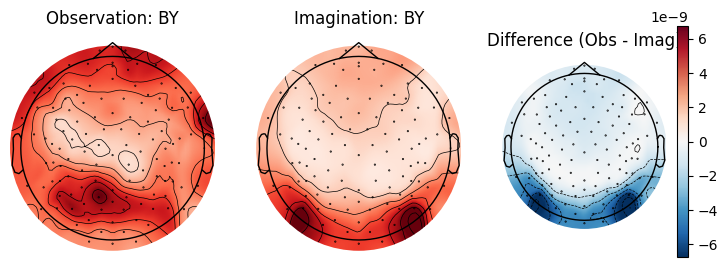

  Muscle artifacts: []


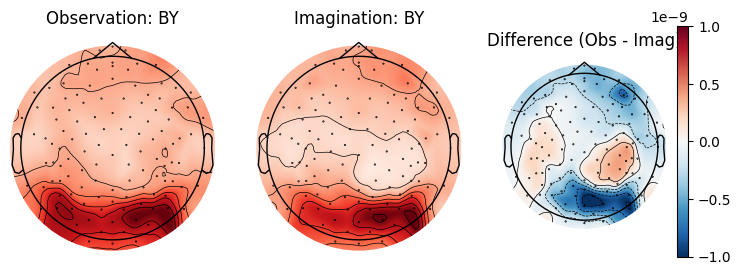

  Muscle artifacts: []


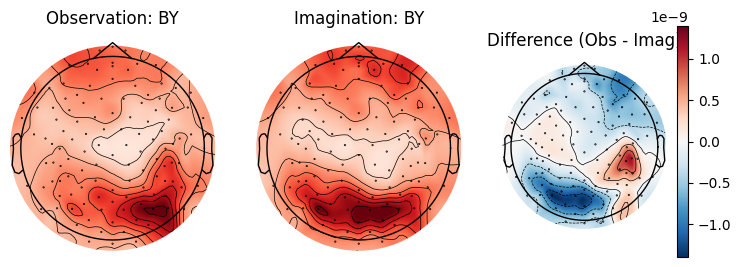

S119
  Muscle artifacts: []


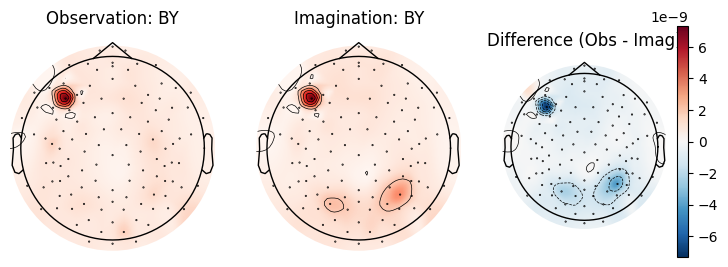

  Muscle artifacts: []


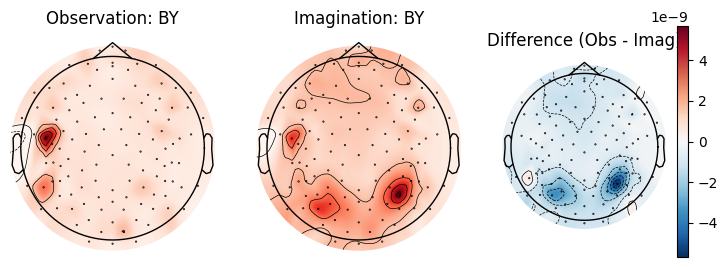

FileNotFoundError: Could not find any EEG data in the 0 files found in /Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S119/VI_S8_S1_B3__20251119_053757.mff:


In [13]:
for subject,files in subject_dirs.items():
    print(f"{subject}")
    for file_name in files:
        file_path = os.path.join(base_dir,subject, file_name)
        processor = preprocessing_pipeline(file_path, *channel_tuple)
        class_results, info = processor.extract_for_topomap()
        plot_topo_comparison(class_results, info, "BY")



# GNN Scratchpad:


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
# 1.  PLV CONNECTIVITY  →  ADJACENCY MATRIX
# ─────────────────────────────────────────────

def compute_plv(segment: np.ndarray) -> np.ndarray:
    """
    Compute Phase Locking Value matrix for one segment.
    
    Args:
        segment: (n_channels, n_samples)  float32/64
    Returns:
        plv_matrix: (n_channels, n_channels)  values in [0, 1]
    """
    n_ch = segment.shape[0]
    # Analytic signal via Hilbert → instantaneous phase
    from scipy.signal import hilbert
    phases = np.angle(hilbert(segment, axis=1))   # (n_ch, n_samples)
    
    plv = np.zeros((n_ch, n_ch), dtype=np.float32)
    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            delta_phi = phases[i] - phases[j]
            plv_val = np.abs(np.mean(np.exp(1j * delta_phi)))
            plv[i, j] = plv_val
            plv[j, i] = plv_val
    np.fill_diagonal(plv, 1.0)
    return plv


def plv_to_edge_index(plv_matrix: np.ndarray, 
                       threshold: float = 0.3):
    """
    Threshold PLV matrix → sparse edge_index + edge_attr.
    
    Args:
        plv_matrix: (n_channels, n_channels)
        threshold:  keep edges where PLV > threshold
    Returns:
        edge_index: (2, n_edges)  long tensor
        edge_attr:  (n_edges, 1)  float tensor  (PLV weights)
    """
    rows, cols = np.where(plv_matrix > threshold)
    # Remove self-loops (diagonal already handled by fill_diagonal but just in case)
    mask = rows != cols
    rows, cols = rows[mask], cols[mask]
    
    edge_index = torch.tensor(np.stack([rows, cols], axis=0), dtype=torch.long)
    edge_attr  = torch.tensor(plv_matrix[rows, cols], dtype=torch.float32).unsqueeze(1)
    return edge_index, edge_attr


# ─────────────────────────────────────────────
# 2.  NODE FEATURES  FROM  TIME WINDOWS
# ─────────────────────────────────────────────

def extract_node_features(segment: np.ndarray, 
                           sfreq: float = 500.0,
                           window_size: float = 0.6) -> np.ndarray:
    """
    For each channel (node), compute band-power features over 0.6s windows
    then concatenate as the node feature vector.
    
    Feature per window: [mean_power, alpha_power, beta_power, std]
    Final node feature: concatenation across all windows in the 4s segment.
    
    Args:
        segment:     (n_channels, n_samples)
        sfreq:       sampling frequency
        window_size: in seconds
    Returns:
        node_features: (n_channels, n_features)
    """
    from scipy.signal import welch
    
    n_ch, n_samples = segment.shape
    win_samples = int(window_size * sfreq)
    n_windows = n_samples // win_samples
    
    all_features = []
    
    for w in range(n_windows):
        s = w * win_samples
        e = s + win_samples
        chunk = segment[:, s:e]                      # (n_ch, win_samples)
        
        # Welch PSD per channel for this window
        freqs, psd = welch(chunk, fs=sfreq, nperseg=min(win_samples, 128), axis=1)
        
        alpha_mask = (freqs >= 8)  & (freqs <= 13)
        beta_mask  = (freqs >= 14) & (freqs <= 26)
        
        alpha_power = psd[:, alpha_mask].mean(axis=1)   # (n_ch,)
        beta_power  = psd[:, beta_mask].mean(axis=1)    # (n_ch,)
        mean_power  = psd.mean(axis=1)                  # (n_ch,)
        std_amp     = chunk.std(axis=1)                 # (n_ch,)
        
        # Stack → (n_ch, 4)
        window_feat = np.stack([mean_power, alpha_power, beta_power, std_amp], axis=1)
        all_features.append(window_feat)
    
    # Concatenate across windows → (n_ch, 4 * n_windows)
    node_features = np.concatenate(all_features, axis=1).astype(np.float32)
    return node_features


# ─────────────────────────────────────────────
# 3.  DATASET BUILDER
# ─────────────────────────────────────────────

def build_graph_dataset(pipeline, 
                         plv_threshold: float = 0.3,
                         label_dict: dict = None) -> list:
    """
    Converts preprocessed pipeline output into a list of PyG Data objects.
    One graph per 4s OS→OE segment.
    
    Args:
        pipeline:      fitted preprocessing_pipeline instance
        plv_threshold: edge inclusion threshold
        label_dict:    e.g. {'OSBA': 0, 'OSBY': 1, ...}
    Returns:
        graph_list: list of torch_geometric.data.Data
    """
    classes = ['BA', 'BY', 'DO', 'MO', 'SI']
    
    if label_dict is None:
        label_dict = {f'OS{cls}': i for i, cls in enumerate(classes)}
    
    graph_list = []
    
    for cls in classes:
        starts = [ann['onset'] for ann in pipeline.annotations 
                  if ann['description'] == f'OS{cls}']
        ends   = [ann['onset'] for ann in pipeline.annotations 
                  if ann['description'] == f'OE{cls}']
        
        for start, end in zip(starts, ends):
            segment = pipeline.raw.copy().crop(tmin=start, tmax=end)
            data_arr = segment.get_data(picks='eeg').astype(np.float32)
            # data_arr: (n_channels, n_samples)
            
            # --- Adjacency: PLV over full 4s segment ---
            plv_mat = compute_plv(data_arr)
            edge_index, edge_attr = plv_to_edge_index(plv_mat, threshold=plv_threshold)
            
            # --- Node features: band power over 0.6s windows ---
            node_feat = extract_node_features(data_arr, 
                                               sfreq=pipeline.fs,
                                               window_size=pipeline.time_window)
            # node_feat: (n_channels, n_features)
            
            x = torch.tensor(node_feat, dtype=torch.float32)
            y = torch.tensor([label_dict[f'OS{cls}']], dtype=torch.long)
            
            graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
            graph_list.append(graph)
    
    print(f"  Built {len(graph_list)} graphs | "
          f"Nodes: {graph_list[0].num_nodes} | "
          f"Node feature dim: {graph_list[0].x.shape[1]} | "
          f"Avg edges: {np.mean([g.num_edges for g in graph_list]):.0f}")
    
    return graph_list


# ─────────────────────────────────────────────
# 4.  GNN MODEL  (GAT + residual + dropout)
# ─────────────────────────────────────────────

class EEG_GAT(nn.Module):
    """
    Graph Attention Network for EEG visual imagery classification.
    
    Architecture:
        GATConv(in  → 64, heads=4)  →  residual proj
        GATConv(256 → 64, heads=4)  →  residual
        GATConv(256 → 64, heads=1)
        GlobalMeanPool
        MLP(64 → 128 → n_classes)
    """
    def __init__(self, in_channels: int, n_classes: int = 5,
                 hidden: int = 64, heads: int = 4, dropout: float = 0.4):
        super().__init__()
        
        self.dropout = dropout
        
        # GAT layers
        self.conv1 = GATConv(in_channels, hidden, heads=heads, 
                              edge_dim=1, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, heads=heads,
                              edge_dim=1, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, hidden, heads=1,
                              edge_dim=1, dropout=dropout)
        
        # Residual projections (to match dimensions after concatenation)
        self.res1 = nn.Linear(in_channels,    hidden * heads)
        self.res2 = nn.Linear(hidden * heads, hidden * heads)
        self.res3 = nn.Linear(hidden * heads, hidden)
        
        # Batch norms
        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)
        
        # Classifier MLP
        self.mlp = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )
    
    def forward(self, x, edge_index, edge_attr, batch):
        # Layer 1
        h = self.conv1(x, edge_index, edge_attr)
        h = self.bn1(h)
        h = F.elu(h + self.res1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        # Layer 2
        h2 = self.conv2(h, edge_index, edge_attr)
        h2 = self.bn2(h2)
        h2 = F.elu(h2 + self.res2(h))
        h2 = F.dropout(h2, p=self.dropout, training=self.training)
        
        # Layer 3
        h3 = self.conv3(h2, edge_index, edge_attr)
        h3 = self.bn3(h3)
        h3 = F.elu(h3 + self.res3(h2))
        
        # Global pooling: aggregate all node embeddings → graph embedding
        graph_emb = global_mean_pool(h3, batch)   # (batch_size, hidden)
        
        return self.mlp(graph_emb)


# ─────────────────────────────────────────────
# 5.  TRAINING  LOOP
# ─────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(dim=1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        out  = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(dim=1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


def train_gnn(graph_list: list,
              n_classes:  int   = 5,
              epochs:     int   = 100,
              lr:         float = 1e-3,
              batch_size: int   = 8,
              n_folds:    int   = 5,
              device_str: str   = 'auto'):
    """
    Stratified K-Fold cross-validation training loop.
    
    Args:
        graph_list: output of build_graph_dataset()
        n_classes:  number of output classes
        epochs:     training epochs per fold
        lr:         learning rate
        batch_size: graphs per batch
        n_folds:    cross-validation folds
        device_str: 'auto', 'cpu', or 'cuda'
    """
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
        if device_str == 'auto' else device_str
    )
    print(f"\n Using device: {device}")
    
    labels  = np.array([g.y.item() for g in graph_list])
    in_dim  = graph_list[0].x.shape[1]
    
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(graph_list, labels)):
        print(f"\n{'─'*40}")
        print(f"  Fold {fold+1}/{n_folds}")
        
        train_graphs = [graph_list[i] for i in train_idx]
        val_graphs   = [graph_list[i] for i in val_idx]
        
        train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_graphs,   batch_size=batch_size, shuffle=False)
        
        model     = EEG_GAT(in_channels=in_dim, n_classes=n_classes).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        criterion = nn.CrossEntropyLoss()
        
        best_val_acc = 0.0
        for epoch in range(1, epochs + 1):
            tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
            va_loss, va_acc = eval_epoch(model,  val_loader,   criterion, device)
            scheduler.step()
            
            if va_acc > best_val_acc:
                best_val_acc = va_acc
                torch.save(model.state_dict(), f'best_fold{fold+1}.pt')
            
            if epoch % 10 == 0:
                print(f"  Epoch {epoch:3d} | "
                      f"Train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
                      f"Val loss {va_loss:.3f} acc {va_acc:.3f}")
        
        fold_accs.append(best_val_acc)
        print(f"  ✅ Best val acc fold {fold+1}: {best_val_acc:.4f}")
    
    print(f"\n{'═'*40}")
    print(f"  Mean val acc: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")
    return fold_accs


# ─────────────────────────────────────────────
# 6.  ENTRY POINT
# ─────────────────────────────────────────────

if __name__ == '__main__':
    # --- 1. Run your pipeline ---
    bad_chs = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125',
               'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114']
    active_chs = []  # fill in if needed

    pipeline = preprocessing_pipeline(
        'your_file.raw',
        active_chs, bad_chs,
        l_freq=8.0, h_freq=26.0,
        apply_ica=True, remove_muscle=True
    )

    # --- 2. Build graph dataset ---
    label_dict = {f'OS{cls}': i for i, cls in enumerate(['BA', 'BY', 'DO', 'MO', 'SI'])}
    graphs = build_graph_dataset(pipeline, plv_threshold=0.3, label_dict=label_dict)

    # --- 3. Train ---
    fold_accuracies = train_gnn(graphs, n_classes=5, epochs=100, lr=1e-3, batch_size=8)